# Crosspower and Coherence Significance

In this script, we repeat the crosspower and coherence calculations, but now we assess whether any relationships identified are different from stochastic noise, and therefore whether they are statistically significant.

In [5]:

# Import needed libraries
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import seaborn as sns
import import_ipynb
import pickle as pkl

# importing wavelet functions and plotting utilities
from wavelets_wrapper_posh.quick_wavelet import run_full_wavelet_analysis, run_double_wavelet_analysis, unmirror_wavelet_power, unmirror_icwt, unmirror_crosspower, unmirror_coherence, unmirror_phase
from wavelets_wrapper_posh.plot_utils import plot_wavelet_power, plot_coherence, plot_phase

# import functions to estimate significance thresholds
from wavelets_wrapper_posh.significance_ar1 import estimate_significance_threshold_crosswavelet

# define fig directory
picture_dir = './figures'

# import the dataframe
data = pd.read_csv('./data/EVI_precip_table_site_12b.csv')
data['Date'] = pd.to_datetime(data['Date'])

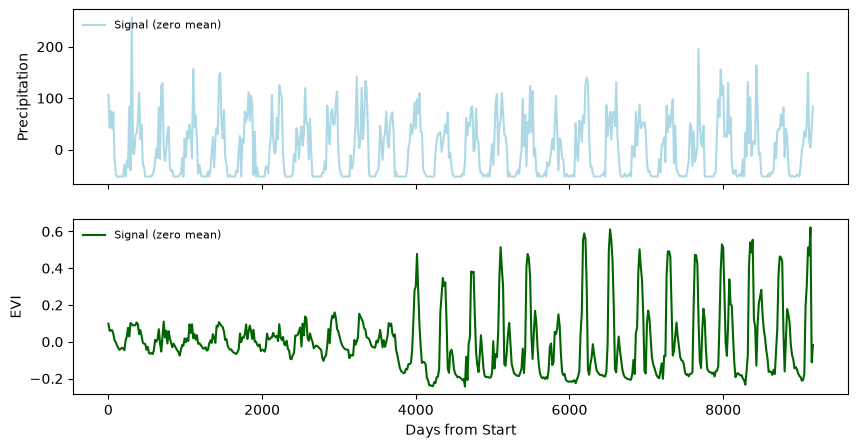

In [3]:
# extract the EVI and precipitation series as arrays
sig_evi = data['EVI'].values
sig_prec = data['Precipitation'].values
days_from_start = data['Days_from_Start'].values

# zero mean the data
sig_prec_zero_mean = sig_prec - np.mean(sig_prec)
sig_evi_zero_mean = sig_evi - np.mean(sig_evi)

# plot 
fig, ax = plt.subplots(figsize=(10,5), nrows=2, ncols=1, sharex=True)
for i, signal in enumerate([sig_prec_zero_mean, sig_evi_zero_mean]):
    color  = 'lightblue' if np.array_equal(signal, sig_prec_zero_mean) else 'darkgreen'
    ylabel = 'Precipitation' if np.array_equal(signal, sig_prec_zero_mean) else 'EVI'
    ax[i].plot(days_from_start, signal, label='Signal (zero mean)', color=color)
    if i == 0:
        ax[i].set_xlabel('')
    else:
        ax[i].set_xlabel('Days from Start')
    ax[i].set_ylabel(ylabel)
    ax[i].legend(loc='upper left', fontsize=8, frameon=False)

In [7]:
# run coherence + cross-wavelet
_, _, _, _, _, wp_env, _, _, _, _, _, wp_evi, xypower_df, phasexy_df, R2ns_df, _, _, _ = run_double_wavelet_analysis(
    sig_prec_zero_mean, sig_evi_zero_mean,
    dt=16, mirror=True, wf='morlet',
    dj=0.1, om0=6, normmean=True,
    mirrormethod=3, period_min=5, period_max=20,
)

# unmirror
period_max_val=len(sig_prec_zero_mean)*16-16 
print(f"Period max value: {period_max_val}")

wp_env, sumpow_env = unmirror_wavelet_power(
    sig_prec_zero_mean, wp_env,
    period_min=20, period_max=period_max_val,
)
wp_evi, sumpow_evi = unmirror_wavelet_power(
    sig_evi_zero_mean, wp_evi,
    period_min=20, period_max=period_max_val,
)
xypower, xysumpow = unmirror_crosspower(
    sig_prec_zero_mean, xypower_df,
    period_min=20, period_max=period_max_val,
)
phasexy = unmirror_phase(
    sig_prec_zero_mean, phasexy_df,
    period_min=20, period_max=period_max_val,
)
R2ns, R2ns_sumpow = unmirror_coherence(
    sig_evi_zero_mean, R2ns_df,
    period_min=20, period_max=period_max_val,
)
    
    
# Significance treshold for cross-wavelet power, this will take long because it runs 1000 simulations of the cross-wavelet power and coherence
significance_tresholds_dict = estimate_significance_threshold_crosswavelet(sig_prec_zero_mean, 
                                                                            sig_evi_zero_mean,
                                                                            n_ensemble=1000, n=None, dt=16, 
                                                                            max_period=None, alpha=None)

# save dictionary results
results_dict = {
    "prec_power": wp_env,
    "prec_power_sumpow": sumpow_env,
    "evi_power": wp_evi,
    "evi_power_sumpow": sumpow_evi,
    "crosswavelet": xypower,
    "crosswavelet_sumpow": xysumpow,
    "coherence": R2ns,
    "coherence_sumpow": R2ns_sumpow,
    "phase": phasexy,
    "crosswavelet_significance": significance_tresholds_dict["crosspower"],
    "coherence_significance": significance_tresholds_dict["coherence"],
    "crosspower_significance_sumpow": significance_tresholds_dict["crosspower_sumpow"],
    "coherence_significance_sumpow": significance_tresholds_dict["coherence_sumpow"]
    }

# Might take a long time to compute, so save results to pkl file so easier for plotting later on
with open(f"results_python.pkl", "wb") as f:
            pkl.dump(results_dict, f)


Calculating coherence with pycwt...

Period max value: 9168
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle removed.
No seasonal cycle rem